# Simulation summary statistics for downstream analysis

Choose a simulation for downstream variant forecasting tasks based on a selection of summary statistics that describe H3N2 HA flu populations in the literature 

## Package Imports

In [1]:
import os
import json
import glob
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

## Helper functions

In [2]:
def summarize_stats(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """Calculate mean and std dev for specified columns."""
    summary = pd.DataFrame({
        'statistic': columns,
        'mean': [df[col].mean() for col in columns],
        'std_dev': [df[col].std() for col in columns]
    })
    return summary

## Load sweep results

In [3]:
build = 'flu-final'
stats_path = f'../data/{build}/antigen-outputs/sim_stats.csv'

In [4]:
stats_df = pd.read_csv(stats_path)
stats_df['run'] = stats_df['run'].astype(int)

# Fix non_epitope_acceptance and epitope_acceptance by parsing from path
# Path format: simulations/nonEpitopeAcceptance_X_epitopeAcceptance_Y/run_Z
stats_df['non_epitope_acceptance'] = stats_df['path'].str.extract(r'nonEpitopeAcceptance_(\d+\.?\d*)')[0].astype(float)
stats_df['epitope_acceptance'] = stats_df['path'].str.extract(r'epitopeAcceptance_(\d+\.?\d*)')[0].astype(float)

# Drop duplicates rows of path if any
stats_df = stats_df.drop_duplicates(subset=['path'])

print(f"Total runs: {stats_df.shape[0]}")

stats_df.head()

Total runs: 120


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,serialInterval,tmrca,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,non_epitope_acceptance,epitope_acceptance
0,experiments/2026-01-06-mutation-bug-fix-runs/s...,21,141398.1899,90000000.0,0.0,8.985860e+07,0.5790,1.401620,198051.1515,3.7690,...,0.01370,3.6036,1229,0.730678,1682,76,1.583333,48,0.1,0.75
1,experiments/2026-01-06-mutation-bug-fix-runs/s...,22,131017.4595,90000000.0,0.0,8.986898e+07,0.5976,1.379322,183541.6181,3.9501,...,0.01367,3.7483,1222,0.757125,1614,52,1.677419,31,0.1,0.75
2,experiments/2026-01-06-mutation-bug-fix-runs/s...,14,137493.8152,90000000.0,0.0,8.986251e+07,0.5787,1.554334,192580.9738,3.2449,...,0.01366,3.0697,1274,0.767470,1660,35,35.000000,1,0.1,0.75
3,experiments/2026-01-06-mutation-bug-fix-runs/s...,2,148921.8919,90000000.0,0.0,8.985108e+07,0.5024,1.545423,208577.0492,3.2205,...,0.01367,3.0008,1318,0.801216,1645,46,9.200000,5,0.1,0.75
4,experiments/2026-01-06-mutation-bug-fix-runs/s...,10,153432.8971,90000000.0,0.0,8.984657e+07,0.6560,1.635082,214893.4051,3.6718,...,0.01372,3.4991,1293,0.783162,1651,47,6.714286,7,0.1,0.75


## Subset to valid runs

In [5]:
# ONly choose runs with diversity < 9.0 and TMRCA <= 5.0 years
filtered_stats_df = stats_df[(stats_df['diversity'] < 9.0) & (stats_df['tmrca'] <= 5.0)]
print(f"Number of valid runs: {filtered_stats_df.shape[0]} vs total runs: {stats_df.shape[0]}")
filtered_stats_df.head()

Number of valid runs: 83 vs total runs: 120


,path,run,I,N,R,S,antigenicDiversity,antigenic_movement_per_year,cases,diversity,...,serialInterval,tmrca,side_branch_epitope_mutations,side_branch_epitope_to_non-epitope_ratio,side_branch_non-epitope_mutations,trunk_epitope_mutations,trunk_epitope_to_non-epitope_ratio,trunk_non-epitope_mutations,non_epitope_acceptance,epitope_acceptance
0,experiments/2026-01-06-mutation-bug-fix-runs/s...,21,141398.1899,90000000.0,0.0,8.985860e+07,0.5790,1.401620,198051.1515,3.7690,...,0.01370,3.6036,1229,0.730678,1682,76,1.583333,48,0.1,0.75
1,experiments/2026-01-06-mutation-bug-fix-runs/s...,22,131017.4595,90000000.0,0.0,8.986898e+07,0.5976,1.379322,183541.6181,3.9501,...,0.01367,3.7483,1222,0.757125,1614,52,1.677419,31,0.1,0.75
2,experiments/2026-01-06-mutation-bug-fix-runs/s...,14,137493.8152,90000000.0,0.0,8.986251e+07,0.5787,1.554334,192580.9738,3.2449,...,0.01366,3.0697,1274,0.767470,1660,35,35.000000,1,0.1,0.75
3,experiments/2026-01-06-mutation-bug-fix-runs/s...,2,148921.8919,90000000.0,0.0,8.985108e+07,0.5024,1.545423,208577.0492,3.2205,...,0.01367,3.0008,1318,0.801216,1645,46,9.200000,5,0.1,0.75
4,experiments/2026-01-06-mutation-bug-fix-runs/s...,10,153432.8971,90000000.0,0.0,8.984657e+07,0.6560,1.635082,214893.4051,3.6718,...,0.01372,3.4991,1293,0.783162,1651,47,6.714286,7,0.1,0.75


## Antigenic and genealogical summary stats

In [6]:
base_stats_path = '../../antigen-tex/figures/figureS1_base_antigen_summary_stats'

Figure saved to ../../antigen-tex/figures/figureS1_base_antigen_summary_stats.pdf and ../../antigen-tex/figures/figureS1_base_antigen_summary_stats.png


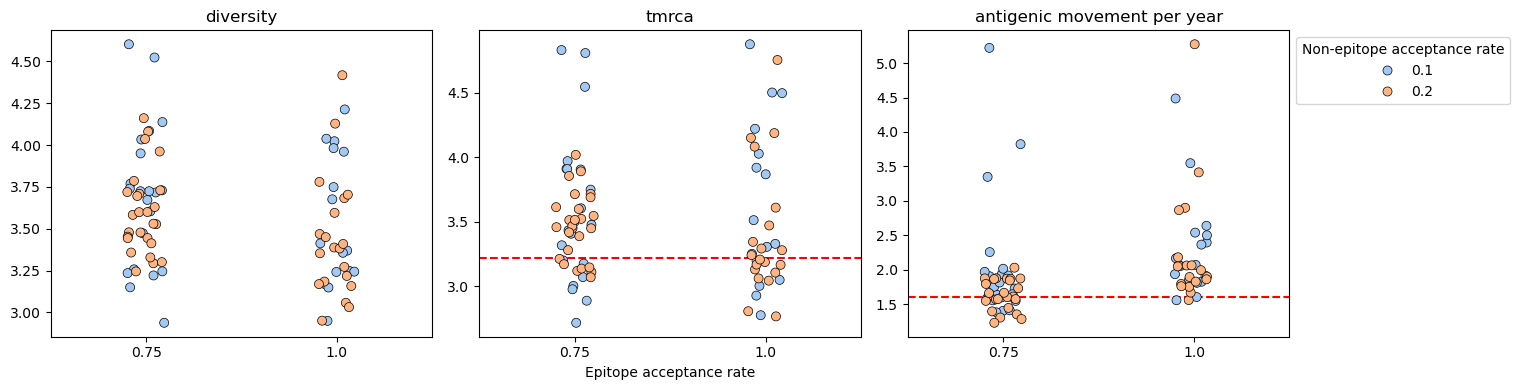

In [9]:
# Specify the columns you want to plot
columns_to_plot = ['diversity', 'tmrca', 'antigenic_movement_per_year']
columns_avgs = [9, 3.22, 1.6, 0.0]
column_avgs_dict = dict(zip(columns_to_plot, columns_avgs))
n_rows = 1
n_cols = 3

# Set up a grid of subplots with 1 rows and 3 columns
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4), sharex=True)
col_idx = 0
for i in range(n_cols):
    column = columns_to_plot[col_idx]
    col_idx += 1
    sns.stripplot(x='epitope_acceptance', y=column, hue='non_epitope_acceptance', data=filtered_stats_df, ax=axes[i], 
                  jitter=True, size=6.5, edgecolor='black', linewidth=0.5, palette='pastel')
    if i > 0:
        axes[i].axhline(column_avgs_dict[column], ls='--', color='red')
    axes[i].set_ylabel('')
    axes[i].set_title(column.replace('_', ' '))
    axes[i].get_legend().remove()
    if i == 1:
        axes[i].set_xlabel('Epitope acceptance rate')
    else:
        axes[i].set_xlabel('')
    
# Add text to upper left corner of first plot
#axes[0].text(-0.2, 1.05, 'A', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top')
axes[2].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title='Non-epitope acceptance rate')

# Layout
plt.tight_layout(rect=[0, 0, 0.85, 1])

# Save the figure in both PDF and PNG formats and show
plt.savefig(f'{base_stats_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{base_stats_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {base_stats_path}.pdf and {base_stats_path}.png")
# Show the plot
plt.show()

In [9]:
# Example usage
summarize_stats(filtered_stats_df, ['diversity', 'tmrca', 'antigenic_movement_per_year'])

,statistic,mean,std_dev
0,diversity,3.574325,0.365266
1,tmrca,3.514427,0.502257
2,antigenic_movement_per_year,2.025602,0.761188


## Sequence mutation summary stats

In [10]:
new_stats_path = '../../antigen-tex/figures/figureS2_new_antigen_summary_stats'

Figure saved to ../../antigen-tex/figures/figureS2_new_antigen_summary_stats.pdf and ../../antigen-tex/figures/figureS2_new_antigen_summary_stats.png


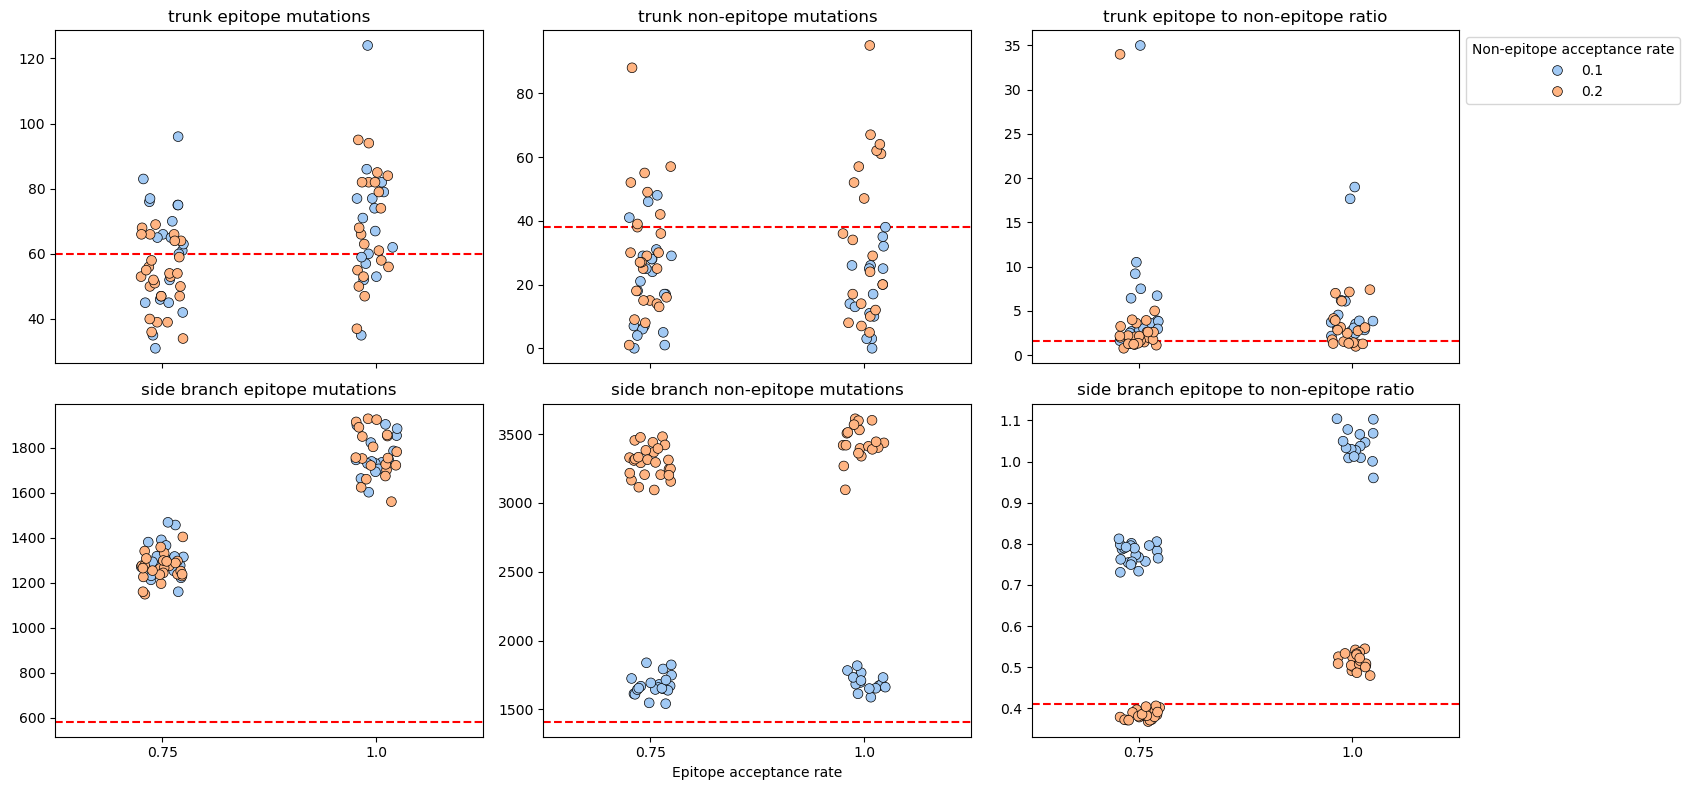

In [12]:
columns_to_plot = ['trunk_epitope_mutations', 'trunk_non-epitope_mutations', 'trunk_epitope_to_non-epitope_ratio', 'side_branch_epitope_mutations', 'side_branch_non-epitope_mutations', 'side_branch_epitope_to_non-epitope_ratio']
columns_avgs = [60, 38, 1.56, 582, 1412, 0.41]
column_avgs_dict = dict(zip(columns_to_plot, columns_avgs))
n_rows = 2
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows), sharex=True)
for i in range(n_rows):
    for j in range(n_cols):
        column = columns_to_plot[i*n_cols + j]
        sns.stripplot(x='epitope_acceptance', y=column, hue='non_epitope_acceptance', data=filtered_stats_df, ax=axes[i,j], 
                      jitter=True, size=7.0, edgecolor='black', linewidth=0.5, palette='pastel')
        axes[i,j].set_title(column.replace('_', ' '))
        axes[i,j].axhline(column_avgs_dict[column], ls='--', color='red')
        # Remove legend
        axes[i,j].get_legend().remove()
        if j == 1 and i == 1:
            axes[i,j].set_xlabel('Epitope acceptance rate')
        else:
            axes[i,j].set_xlabel('')
        axes[i,j].set_ylabel('')
# Add legend outside of plot
axes[0,2].legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), title='Non-epitope acceptance rate')

# Add text to upper left corner of first plot
#axes[0,0].text(-0.2, 1.05, 'B', transform=axes[0,0].transAxes, fontsize=16, fontweight='bold', va='top')
# Adjust the layout of the subplots
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(f'{new_stats_path}.pdf', dpi=300, bbox_inches='tight')
plt.savefig(f'{new_stats_path}.png', dpi=300, bbox_inches='tight')
print(f"Figure saved to {new_stats_path}.pdf and {new_stats_path}.png")
# Show the plot
plt.show()

In [51]:
summarize_stats(subset_stats_df, columns_to_plot)

,statistic,mean,std_dev
0,trunk_epitope_mutations,56.350000,15.277348
1,trunk_non-epitope_mutations,41.550000,29.346344
2,trunk_epitope_to_non-epitope_ratio,2.864540,4.170094
3,side_branch_epitope_mutations,1268.350000,92.705689
4,side_branch_non-epitope_mutations,4154.950000,175.209491
5,side_branch_epitope_to_non-epitope_ratio,0.304986,0.012323
